# ***Youtube Data Analysis***
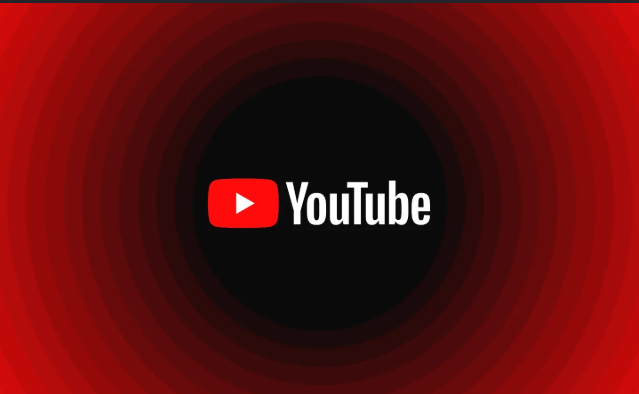

# ***API***

In [3]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

API_KEY = userdata.get('Youtube_API_Key')

search_queries = ['Data Analysis', 'Data Analytics']
all_data = []

for query in search_queries:
    search_url = "https://www.googleapis.com/youtube/v3/search"
    search_params = {
        'key': API_KEY,
        'q': query,
        'part': 'snippet',
        'type': 'video',
        'maxResults': 50
    }

    search_res = requests.get(search_url, params=search_params).json()

    for item in search_res.get('items', []):
        video_id = item.get('id', {}).get('videoId')
        if not video_id:
            continue

        snippet = item.get('snippet', {})
        video_title = snippet.get('title')
        channel_title = snippet.get('channelTitle')

        description = snippet.get('description')
        if not description or description.strip() == "":
            description = None

        video_details_url = "https://www.googleapis.com/youtube/v3/videos"
        v_params = {
            'key': API_KEY,
            'id': video_id,
            'part': 'statistics'
        }
        v_res = requests.get(video_details_url, params=v_params).json()

        stats = {}
        if v_res.get('items'):
            stats = v_res['items'][0].get('statistics', {})

        likes = stats.get('likeCount', None)
        views = stats.get('viewCount', None)

        comments_url = "https://www.googleapis.com/youtube/v3/commentThreads"
        c_params = {
            'key': API_KEY,
            'videoId': video_id,
            'part': 'snippet',
            'maxResults': 20,
            'order': 'relevance'
        }

        c_res = requests.get(comments_url, params=c_params).json()

        if 'items' in c_res:
            for c_item in c_res['items']:
                comment_snippet = c_item['snippet']['topLevelComment']['snippet']

                comment_text = comment_snippet.get('textDisplay')
                if comment_text and comment_text.strip() == "":
                    comment_text = None

                comment_likes = comment_snippet.get('likeCount', None)

                all_data.append({
                    'video_id': video_id,
                    'video_title': video_title,
                    'channel_title': channel_title,
                    'video_description': description,
                    'video_views': views,
                    'video_likes': likes,
                    'comment_text': comment_text,
                    'comment_likes': comment_likes
                })

df = pd.DataFrame(all_data)

In [4]:
#df.to_csv('Youtube_Data_G6.csv', index=False)

# ***EDA & Data Cleaning***

In [5]:
data = pd.read_csv('/content/Youtube_Data_G6.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/content/Youtube_Data_G6.csv'

In [ ]:
data.head()

,video_id,video_title,channel_title,video_description,video_views,video_likes,comment_text,comment_likes
0,yZvFH7B6gKI,What Is Data Analytics? - An Introduction (Ful...,CareerFoundry,Curious about a career in Data Analytics? Book...,2186837,51450.0,Next Steps - Subscribe for our channel for mor...,120
1,yZvFH7B6gKI,What Is Data Analytics? - An Introduction (Ful...,CareerFoundry,Curious about a career in Data Analytics? Book...,2186837,51450.0,I am currently studying SQL and soon will cont...,59
2,yZvFH7B6gKI,What Is Data Analytics? - An Introduction (Ful...,CareerFoundry,Curious about a career in Data Analytics? Book...,2186837,51450.0,As someone who has spent years in data science...,215
3,yZvFH7B6gKI,What Is Data Analytics? - An Introduction (Ful...,CareerFoundry,Curious about a career in Data Analytics? Book...,2186837,51450.0,“Nothing can&#39;t be learned over time with p...,223
4,yZvFH7B6gKI,What Is Data Analytics? - An Introduction (Ful...,CareerFoundry,Curious about a career in Data Analytics? Book...,2186837,51450.0,"If you&#39;re reading this right now, I just w...",376


In [ ]:
data.shape

(1837, 8)

In [ ]:
print(f"Total Number of Duplicates:  {data.duplicated().sum()}")

Total Number of Duplicates:  481


In [ ]:
print(f"Total Number of Missing Values:  {data.isna().sum()}")

Total Number of Missing Values:  video_id              0
video_title           0
channel_title         0
video_description    85
video_views           0
video_likes          79
comment_text          0
comment_likes         0
dtype: int64


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1837 entries, 0 to 1836
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   video_id           1837 non-null   object 
 1   video_title        1837 non-null   object 
 2   channel_title      1837 non-null   object 
 3   video_description  1752 non-null   object 
 4   video_views        1837 non-null   int64  
 5   video_likes        1758 non-null   float64
 6   comment_text       1837 non-null   object 
 7   comment_likes      1837 non-null   int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 114.9+ KB


In [ ]:
duplicates = data[data.duplicated(keep=False)]
duplicates.sort_values(by=list(data.columns), inplace=True)

duplicates.head(10)

/tmp/ipykernel_10545/1209165525.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  duplicates.sort_values(by=list(data.columns), inplace=True)


,video_id,video_title,channel_title,video_description,video_views,video_likes,comment_text,comment_likes
514,61vK_MliOSM,Data Analytics Explained: The 21 Most Importan...,Lore So What,"Join my Academy, learn Data & AI skills and la...",49096,1893.0,All concepts covered nicely in a single brief ...,1
1824,61vK_MliOSM,Data Analytics Explained: The 21 Most Importan...,Lore So What,"Join my Academy, learn Data & AI skills and la...",49096,1893.0,All concepts covered nicely in a single brief ...,1
511,61vK_MliOSM,Data Analytics Explained: The 21 Most Importan...,Lore So What,"Join my Academy, learn Data & AI skills and la...",49096,1893.0,Amazing,0
1821,61vK_MliOSM,Data Analytics Explained: The 21 Most Importan...,Lore So What,"Join my Academy, learn Data & AI skills and la...",49096,1893.0,Amazing,0
522,61vK_MliOSM,Data Analytics Explained: The 21 Most Importan...,Lore So What,"Join my Academy, learn Data & AI skills and la...",49096,1893.0,"As always, well done!",1
1832,61vK_MliOSM,Data Analytics Explained: The 21 Most Importan...,Lore So What,"Join my Academy, learn Data & AI skills and la...",49096,1893.0,"As always, well done!",1
509,61vK_MliOSM,Data Analytics Explained: The 21 Most Importan...,Lore So What,"Join my Academy, learn Data & AI skills and la...",49096,1893.0,"Awesome explanation of concepts bro!<a href=""U...",8
1819,61vK_MliOSM,Data Analytics Explained: The 21 Most Importan...,Lore So What,"Join my Academy, learn Data & AI skills and la...",49096,1893.0,"Awesome explanation of concepts bro!<a href=""U...",8
507,61vK_MliOSM,Data Analytics Explained: The 21 Most Importan...,Lore So What,"Join my Academy, learn Data & AI skills and la...",49096,1893.0,Awesome summary. I would have expected to incl...,1
1817,61vK_MliOSM,Data Analytics Explained: The 21 Most Importan...,Lore So What,"Join my Academy, learn Data & AI skills and la...",49096,1893.0,Awesome summary. I would have expected to incl...,1


In [ ]:
data.drop_duplicates(inplace=True)

In [ ]:
data[data['video_description'].isnull()]

,video_id,video_title,channel_title,video_description,video_views,video_likes,comment_text,comment_likes
467,Q-Ar-35nChA,Use AI in Excel for Data Analysis | No Plugin ...,Levelupwithexcel,NaN,573323,5454.0,This video has opened my eyes to Excel’s capab...,20
468,Q-Ar-35nChA,Use AI in Excel for Data Analysis | No Plugin ...,Levelupwithexcel,NaN,573323,5454.0,This video is a total game changer! I’ve been ...,15
469,Q-Ar-35nChA,Use AI in Excel for Data Analysis | No Plugin ...,Levelupwithexcel,NaN,573323,5454.0,who knew excel could be this fun 😂,5
470,Q-Ar-35nChA,Use AI in Excel for Data Analysis | No Plugin ...,Levelupwithexcel,NaN,573323,5454.0,I used to be the person drowning in Excel shee...,2
471,Q-Ar-35nChA,Use AI in Excel for Data Analysis | No Plugin ...,Levelupwithexcel,NaN,573323,5454.0,finally an easy way to analyze data!,8
...,...,...,...,...,...,...,...,...
1772,77dPDHiDnM0,Things I wish I knew before Data Analyst inter...,Chidinma Afam,NaN,31007,NaN,Thank you very much for this,0
1773,77dPDHiDnM0,Things I wish I knew before Data Analyst inter...,Chidinma Afam,NaN,31007,NaN,Hello,0
1774,77dPDHiDnM0,Things I wish I knew before Data Analyst inter...,Chidinma Afam,NaN,31007,NaN,Hi. Do u coach upcoming data analyst,0
1775,77dPDHiDnM0,Things I wish I knew before Data Analyst inter...,Chidinma Afam,NaN,31007,NaN,Can I connect with you on LinkedIn.,3


In [ ]:
data['video_description'].fillna('No Description', inplace=True)

/tmp/ipykernel_10545/1888490729.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['video_description'].fillna('No Description', inplace=True)


In [ ]:
data.isna().sum()

,0
video_id,0
video_title,0
channel_title,0
video_description,0
video_views,0
video_likes,69
comment_text,0
comment_likes,0


In [ ]:
data['video_likes'] = data['video_likes'].astype('Int64')

In [ ]:
data['channel_title'].unique()

array(['CareerFoundry', 'Lillian Chiu', 'Kenji Explains',
       'Programming with Mosh', 'Simplilearn', 'Tech Table Tutor',
       'Jeff Su', 'Tina Huang', 'Alex The Analyst', 'Endless Knowledge',
       'Learn Skills Daily', 'Chandoo - Tech in Telugu', 'Simon Sez IT',
       'Luke Barousse', 'Team Lyqa', 'Wale Gbads', 'Agatha', 'Grad Coach',
       'IBM Technology', 'MIT OpenCourseWare', 'Grow with Google',
       'Levelupwithexcel', 'Lore So What', 'CareerRide',
       'Jess Ramos | Data, AI, & Tech ⚡️', 'Chandoo', 'freeCodeCamp.org',
       'Co-Coder', 'Dr Noni ChiExtra', 'Traidev Official ', 'WsCube Tech',
       'Sahil Panwar ', 'Easy to write', 'Andy Stapleton', 'Rohan Adus',
       'MyOnlineTrainingHub', 'Sundas Khalid', 'Career_with_Jaya',
       'HR_Navin', 'Kedeisha Bryan - Your Data Career Coach', 'Sarven N',
       'TEDx Talks', 'Entri Coding മലയാളം ', 'Matt Mike',
       'Christine Jiang', 'Data with Baraa', 'Tina Okonkwo', 'codebasics',
       'Mo Chen', 'Data Logic With

In [ ]:
data.columns = data.columns.str.strip()

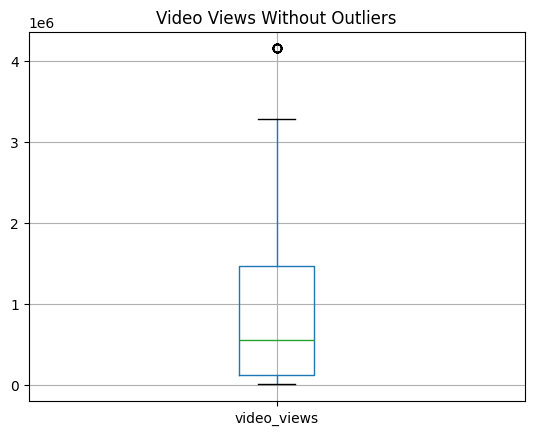

In [ ]:
data.boxplot(column='video_views')
plt.title("Video Views Without Outliers")
plt.show()

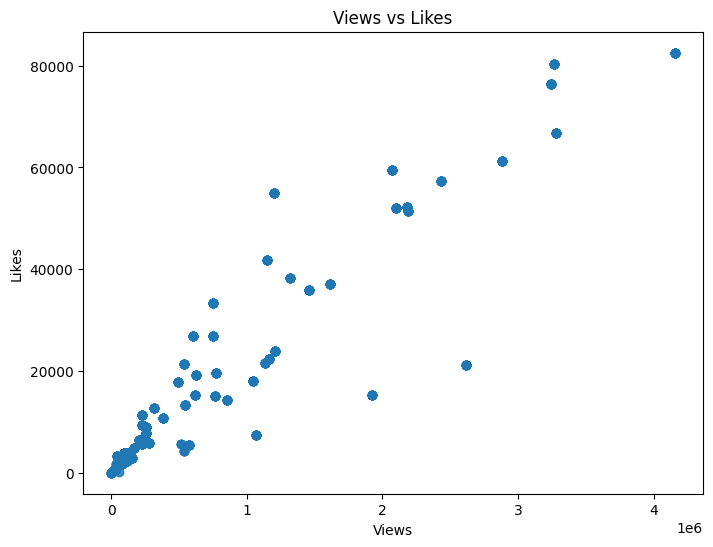

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(data['video_views'], data['video_likes'], alpha=0.6)
plt.xlabel("Views")
plt.ylabel("Likes")
plt.title("Views vs Likes")
plt.show()

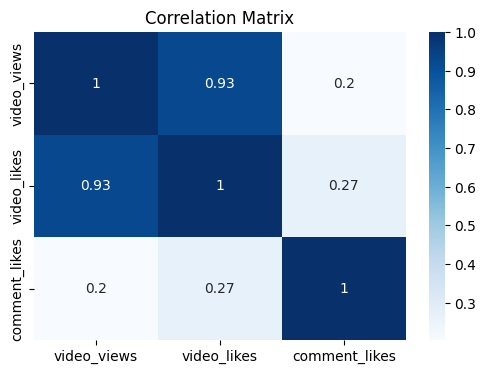

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(
    data[['video_views', 'video_likes', 'comment_likes']].corr(),
    annot=True,
    cmap='Blues'
)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
data.to_csv("Youtube_Data_Cleaned_G6.csv", index=False)

# ***NLP & Sentiment Analysis***

In [ ]:
!pip install ydata-profiling -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 7.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import plotly.express as px
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from ydata_profiling import ProfileReport

/tmp/ipykernel_10545/3369267029.py:9: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [ ]:
data = pd.read_csv('/content/Youtube_Data_Cleaned_G6.csv')

In [ ]:
data.head()

,video_id,video_title,channel_title,video_description,video_views,video_likes,comment_text,comment_likes
0,yZvFH7B6gKI,What Is Data Analytics? - An Introduction (Ful...,CareerFoundry,Curious about a career in Data Analytics? Book...,2186837,51450.0,Next Steps - Subscribe for our channel for mor...,120
1,yZvFH7B6gKI,What Is Data Analytics? - An Introduction (Ful...,CareerFoundry,Curious about a career in Data Analytics? Book...,2186837,51450.0,I am currently studying SQL and soon will cont...,59
2,yZvFH7B6gKI,What Is Data Analytics? - An Introduction (Ful...,CareerFoundry,Curious about a career in Data Analytics? Book...,2186837,51450.0,As someone who has spent years in data science...,215
3,yZvFH7B6gKI,What Is Data Analytics? - An Introduction (Ful...,CareerFoundry,Curious about a career in Data Analytics? Book...,2186837,51450.0,“Nothing can&#39;t be learned over time with p...,223
4,yZvFH7B6gKI,What Is Data Analytics? - An Introduction (Ful...,CareerFoundry,Curious about a career in Data Analytics? Book...,2186837,51450.0,"If you&#39;re reading this right now, I just w...",376


In [ ]:
Youtube_EDA = ProfileReport(data , title="Youtube Data EDA" , explorative=True)

In [ ]:
Youtube_EDA.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 34.70it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
#nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

In [ ]:
stopwards_set = set(stopwords.words("english"))

In [ ]:
def Clean_Text(text):
  text = text.lower()
  text = re.sub(r'[^a-z\s]' , ' ' , text)
  tokens = word_tokenize(text)
  tokens=[i for i in tokens if i not in stopwards_set]
  lemmatizer = WordNetLemmatizer()
  tokens = [lemmatizer.lemmatize(i) for i in tokens]
  return ' '.join(tokens)

In [ ]:
data['comment_text_clean'] = data['comment_text'].apply(Clean_Text)

In [ ]:
data.head(3)

,video_id,video_title,channel_title,video_description,video_views,video_likes,comment_text,comment_likes,comment_text_clean
0,yZvFH7B6gKI,What Is Data Analytics? - An Introduction (Ful...,CareerFoundry,Curious about a career in Data Analytics? Book...,2186837,51450.0,Next Steps - Subscribe for our channel for mor...,120,next step subscribe channel data content href ...
1,yZvFH7B6gKI,What Is Data Analytics? - An Introduction (Ful...,CareerFoundry,Curious about a career in Data Analytics? Book...,2186837,51450.0,I am currently studying SQL and soon will cont...,59,currently studying sql soon continue learning ...
2,yZvFH7B6gKI,What Is Data Analytics? - An Introduction (Ful...,CareerFoundry,Curious about a career in Data Analytics? Book...,2186837,51450.0,As someone who has spent years in data science...,215,someone spent year data science incredible see...


In [ ]:
def Sentiment_Analysis(text):
  P = TextBlob(text).sentiment.polarity
  if P > 0:
    return "Positive"
  elif P < 0:
    return "Negative"
  else:
    return "Neutral"

In [ ]:
data["Sentiment_Analysis"] = data['comment_text_clean'].apply(Sentiment_Analysis)

In [ ]:
data.head(3)

,video_id,video_title,channel_title,video_description,video_views,video_likes,comment_text,comment_likes,comment_text_clean,Sentiment_Analysis
0,yZvFH7B6gKI,What Is Data Analytics? - An Introduction (Ful...,CareerFoundry,Curious about a career in Data Analytics? Book...,2186837,51450.0,Next Steps - Subscribe for our channel for mor...,120,next step subscribe channel data content href ...,Positive
1,yZvFH7B6gKI,What Is Data Analytics? - An Introduction (Ful...,CareerFoundry,Curious about a career in Data Analytics? Book...,2186837,51450.0,I am currently studying SQL and soon will cont...,59,currently studying sql soon continue learning ...,Positive
2,yZvFH7B6gKI,What Is Data Analytics? - An Introduction (Ful...,CareerFoundry,Curious about a career in Data Analytics? Book...,2186837,51450.0,As someone who has spent years in data science...,215,someone spent year data science incredible see...,Positive


In [ ]:
fig = px.pie(data, names='Sentiment_Analysis', title='Sentiment Analysis')
fig.show()

In [ ]:
data.to_csv('Youtube_Data_Cleaned_SA_G6.csv', index=False)

# ***Data Cleaning & ML Models***

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings("ignore")

In [ ]:
data = pd.read_csv('/content/Youtube_Data_Cleaned_SA_G6.csv')
data.head(1)

,video_id,video_title,channel_title,video_description,video_views,video_likes,comment_text,comment_likes,comment_text_clean,Sentiment_Analysis
0,yZvFH7B6gKI,What Is Data Analytics? - An Introduction (Ful...,CareerFoundry,Curious about a career in Data Analytics? Book...,2186837,51450.0,Next Steps - Subscribe for our channel for mor...,120,next step subscribe channel data content href ...,Positive


In [ ]:
data[data['comment_text_clean'].str.strip()==""]

,video_id,video_title,channel_title,video_description,video_views,video_likes,comment_text,comment_likes,comment_text_clean,Sentiment_Analysis


In [ ]:
data["Sentiment_Analysis"].value_counts()

,count
Sentiment_Analysis,
Positive,859
Neutral,413
Negative,84


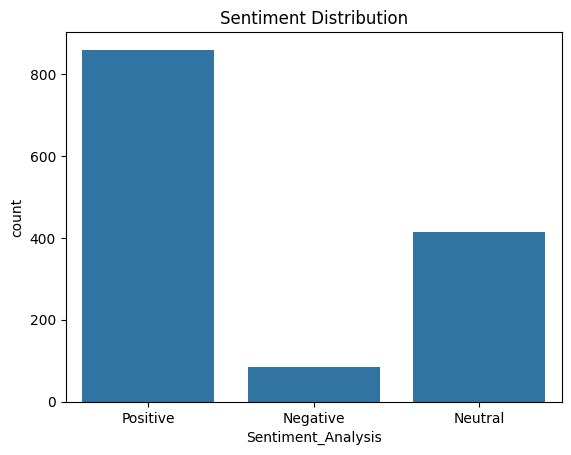

In [ ]:
sns.countplot(data=data, x="Sentiment_Analysis")
plt.title("Sentiment Distribution")
plt.show()

In [ ]:
data[['comment_text_clean','Sentiment_Analysis']].isnull().sum()

,0
comment_text_clean,29
Sentiment_Analysis,0


In [ ]:
data = data.dropna(subset=["comment_text_clean"])
data['comment_text_clean'].isnull().sum()

np.int64(0)

In [ ]:
data[['comment_text_clean','Sentiment_Analysis']].duplicated().sum()

np.int64(86)

In [ ]:
data = data.drop_duplicates(subset=["comment_text_clean", "Sentiment_Analysis"])

In [ ]:
data[['comment_text_clean','Sentiment_Analysis']].duplicated().sum()

np.int64(0)

## ***Encoding for Sentiment Analysis Column***

In [ ]:
encoder=LabelEncoder()
y=encoder.fit_transform(data["Sentiment_Analysis"])

In [ ]:
data.reset_index(drop=True, inplace=True)

(data["comment_text_clean"].str.len() == 0).sum()

np.int64(0)

In [ ]:
tfidf=TfidfVectorizer(max_features=5000)
X=tfidf.fit_transform(data['comment_text_clean'])

In [ ]:
print(f"Shape of X: {X.shape}")
print(f"Shape of Y: {y.shape}")

Shape of X: (1241, 3833)
Shape of Y: (1241,)


## ***Split Data into Train & Test***

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.3,random_state=42,stratify=y)

In [ ]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (868, 3833)
X_test : (373, 3833)
y_train: (868,)
y_test : (373,)


## ***Models***

### *Logisitic Regression*

In [ ]:
lr_model=LogisticRegression(max_iter=1000,random_state=42)
lr_model.fit(X_train,y_train)
lr_pred=lr_model.predict(X_test)

In [ ]:
print(f"Accuracy Score by Logistic Regression: {accuracy_score(y_test,lr_pred):.4f}")

Accuracy Score by Logistic Regression: 0.7265


In [ ]:
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        24
           1       0.82      0.30      0.44       104
           2       0.72      0.98      0.83       245

    accuracy                           0.73       373
   macro avg       0.51      0.43      0.42       373
weighted avg       0.70      0.73      0.67       373



In [ ]:
cm=confusion_matrix(y_test,lr_pred)
print(cm)

[[  0   2  22]
 [  0  31  73]
 [  0   5 240]]


### *Naive Bayse*

In [ ]:
nb_model=MultinomialNB()
nb_model.fit(X_train,y_train)
nb_predict=nb_model.predict(X_test)

In [ ]:
print(f"Accuracy Score by Naive Bayes: {accuracy_score(y_test,nb_predict):.4f}")

Accuracy Score by Naive Bayes: 0.6783


In [ ]:
print(classification_report(y_test, nb_predict, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        24
           1       0.82      0.09      0.16       104
           2       0.67      1.00      0.80       245

    accuracy                           0.68       373
   macro avg       0.50      0.36      0.32       373
weighted avg       0.67      0.68      0.57       373



In [ ]:
nb_cm = confusion_matrix(y_test, nb_predict)
print(nb_cm)

[[  0   1  23]
 [  0   9  95]
 [  0   1 244]]


### *Support Vector Machine*

In [ ]:
svm_model=LinearSVC(random_state=42)
svm_model.fit(X_train,y_train)
svm_predict=svm_model.predict(X_test)

In [ ]:
print(f"Accuracy Score by SVM : {accuracy_score(y_test,svm_predict):.4f}")

Accuracy Score by SVM : 0.8043


In [ ]:
print(classification_report(y_test, svm_predict, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        24
           1       0.76      0.69      0.72       104
           2       0.83      0.93      0.88       245

    accuracy                           0.80       373
   macro avg       0.53      0.54      0.53       373
weighted avg       0.75      0.80      0.78       373



In [ ]:
svm_cm = confusion_matrix(y_test, svm_predict)
print(svm_cm)

[[  0   6  18]
 [  2  72  30]
 [  0  17 228]]


### *Decision Tree*

In [ ]:
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)
dt_pred=dt_model.predict(X_test)

In [ ]:
print(f"Accuracy Score by Decision Tree : {accuracy_score(y_test,dt_pred):.4f}")

Accuracy Score by Decision Tree : 0.7775


In [ ]:
print(classification_report(y_test, dt_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.25      0.12      0.17        24
           1       0.65      0.83      0.73       104
           2       0.88      0.82      0.85       245

    accuracy                           0.78       373
   macro avg       0.59      0.59      0.58       373
weighted avg       0.77      0.78      0.77       373



In [ ]:
dt_cm = confusion_matrix(y_test, dt_pred)
print(dt_cm)

[[  3   9  12]
 [  2  86  16]
 [  7  37 201]]


### *Random Forest*

In [ ]:
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)
rf_pred=rf_model.predict(X_test)

In [ ]:
print(f"Accuracy Score by Random Forest : {accuracy_score(y_test,rf_pred):.4f}")

Accuracy Score by Random Forest : 0.7641


In [ ]:
print(classification_report(y_test, rf_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        24
           1       0.63      0.73      0.68       104
           2       0.83      0.85      0.84       245

    accuracy                           0.76       373
   macro avg       0.49      0.53      0.51       373
weighted avg       0.72      0.76      0.74       373



In [ ]:
rf_cm = confusion_matrix(y_test, rf_pred)
print(rf_cm)

[[  0   8  16]
 [  0  76  28]
 [  0  36 209]]


### *Final Model*

In [ ]:
print(f"Accuracy Score by SVM : {accuracy_score(y_test,svm_predict):.4f}")
print(f"Accuracy Score by Decision Tree : {accuracy_score(y_test,dt_pred):.4f}")
print(f"Accuracy Score by Random Forest : {accuracy_score(y_test,rf_pred):.4f}")
print(f"Accuracy Score by Logistic Regression: {accuracy_score(y_test,lr_pred):.4f}")
print(f"Accuracy Score by Naive Bayes: {accuracy_score(y_test,nb_predict):.4f}")

Accuracy Score by SVM : 0.8043
Accuracy Score by Decision Tree : 0.7775
Accuracy Score by Random Forest : 0.7641
Accuracy Score by Logistic Regression: 0.7265
Accuracy Score by Naive Bayes: 0.6783


**Model Comparison:**

Five Machine Learning Models were trained and evaluated using the test dataset. Their performance was compared based on the Accuracy metric. Among all Models, **<mark>Linear SVM</mark>** achieved the highest accuracy <mark>`80.43%`</mark>, demonstrating the best overall performance for this sentiment analysis task. It was followed by **<mark>Decision Tree</mark>** <mark>`77.75%`</mark>, **<mark>Random Forest</mark>** <mark>`76.41%`</mark>, **<mark>Logistic Regression</mark>** <mark>`72.65%`</mark>, and **<mark>Naive Bayes</mark>** <mark>`67.83%`</mark>. Therefore, the <mark>**Linear SVM**</mark> model was selected as the <mark>*Final Model*</mark> due to its superior classification performance

## ***Test Model***

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [ ]:
#nltk.download("punkt")
#nltk.download("stopwords")
#nltk.download("wordnet")
#nltk.download("omw-1.4")

In [ ]:
stopwards_set = set(stopwords.words("english"))

In [ ]:
def Clean_Text(text):
  text = text.lower()
  text = re.sub(r'[^a-z\s]' , ' ' , text)
  tokens = word_tokenize(text)
  tokens=[i for i in tokens if i not in stopwards_set]
  lemmatizer = WordNetLemmatizer()
  tokens = [lemmatizer.lemmatize(i) for i in tokens]
  return ' '.join(tokens)

In [ ]:
def predict_sentiment(comment):

    # Clean comment
    clean_comment = Clean_Text(comment)

    # TF-IDF
    vector = tfidf.transform([clean_comment])

    # Predict
    prediction = svm_model.predict(vector)

    # Decode label
    sentiment = encoder.inverse_transform(prediction)[0]

    print("=" * 40)
    print(f"Original Comment : {comment}")
    print(f"Clean Comment    : {clean_comment}")
    print(f"Predicted Class  : {sentiment}")
    print("=" * 40)

In [ ]:
comment = input("Enter Your Comment: ")
predict_sentiment(comment)

Enter Your Comment: i am Happy
Original Comment : i am Happy
Clean Comment    : happy
Predicted Class  : Positive


In [ ]:
comment = input("Enter Your Comment: ")
predict_sentiment(comment)

Enter Your Comment: i am sad
Original Comment : i am sad
Clean Comment    : sad
Predicted Class  : Negative


In [ ]:
comment = input("Enter Your Comment: ")
predict_sentiment(comment)

Enter Your Comment: Fares
Original Comment : Fares
Clean Comment    : fare
Predicted Class  : Neutral
